In [1]:
import os 
import numpy as np 
import pandas as pd 
from absl import app 
from absl import flags 
from typing import Sequence 
import matplotlib.pyplot as plt

In [2]:
# exp_dir = "../ptest/" 
# exp_dir = "../../../../data/ptest_arr/"
# os.listdir(exp_dir)

# dataset_info = {"exp_dir": "../../../../data/ptest_arr/",}
dataset_info = {"exp_dir": "../../../../data/ptest_arr_dices/", "dataset": "DICES", "num_categories": "3",}
# dataset_info = {"exp_dir": "../../../../data/ptest_arr_d3code/", "dataset": "D3code", "num_categories": "2",}
# dataset_info = {"exp_dir": "../../../../data/ptest_arr_jobsQ1/", "dataset": "JobsQ1", "num_categories": "5",}
# dataset_info = {"exp_dir": "../../../../data/ptest_arr_jobsQ3/", "dataset": "JobsQ3", "num_categories": "12",}

In [3]:
params_list = [] 
all_params_list = [] 
ks = [x for x in range(1,11)] 
ks.extend([x for x in range(20,1001, 20)])

def get_n_k_for_num_ratings(all_values, num_ratings=5000): 
    values=[] 
    for x in all_values:
        if x==0:
            x=1 
        n = int(np.floor(num_ratings/x)) 
        # if n > 30:
        values.append((n, int(x))) 
    return values
# vals = get_n_k_for_num_ratings(ks) 
# [x[1] for x in vals], [x[0] for x in vals]
ratings_list = [] 
# nk_list = [10000, 25000, 50000]
nk_list = [1000, 2500, 5000, 10000, 25000, 50000]
# for r in range(1000, 5001, 1000):
# for r in range(5000, 5001, 500): 
for r in nk_list:
    params = get_n_k_for_num_ratings(ks, r) 
    params_list.append(params)
    all_params_list.extend(params) 
    ratings_list.extend([(r-x[0]*x[1]) for x in params])
    print(params)

[(1000, 1), (500, 2), (333, 3), (250, 4), (200, 5), (166, 6), (142, 7), (125, 8), (111, 9), (100, 10), (50, 20), (25, 40), (16, 60), (12, 80), (10, 100), (8, 120), (7, 140), (6, 160), (5, 180), (5, 200), (4, 220), (4, 240), (3, 260), (3, 280), (3, 300), (3, 320), (2, 340), (2, 360), (2, 380), (2, 400), (2, 420), (2, 440), (2, 460), (2, 480), (2, 500), (1, 520), (1, 540), (1, 560), (1, 580), (1, 600), (1, 620), (1, 640), (1, 660), (1, 680), (1, 700), (1, 720), (1, 740), (1, 760), (1, 780), (1, 800), (1, 820), (1, 840), (1, 860), (1, 880), (1, 900), (1, 920), (1, 940), (1, 960), (1, 980), (1, 1000)]
[(2500, 1), (1250, 2), (833, 3), (625, 4), (500, 5), (416, 6), (357, 7), (312, 8), (277, 9), (250, 10), (125, 20), (62, 40), (41, 60), (31, 80), (25, 100), (20, 120), (17, 140), (15, 160), (13, 180), (12, 200), (11, 220), (10, 240), (9, 260), (8, 280), (8, 300), (7, 320), (7, 340), (6, 360), (6, 380), (6, 400), (5, 420), (5, 440), (5, 460), (5, 480), (5, 500), (4, 520), (4, 540), (4, 560), (4

In [4]:
def get_bash_params_list(all_params_list):
    # print(all_params_list)
    params_str = str(all_params_list)
    params_str = params_str.replace('[','')
    params_str = params_str.replace(']','')
    params_str = params_str.replace(',','')
    params_str = params_str.replace('(','"')
    params_str = params_str.replace(')','"')
    params_str = "(" + params_str + ")"
    return params_str

params_str = get_bash_params_list(all_params_list)
print(params_str)

("1000 1" "500 2" "333 3" "250 4" "200 5" "166 6" "142 7" "125 8" "111 9" "100 10" "50 20" "25 40" "16 60" "12 80" "10 100" "8 120" "7 140" "6 160" "5 180" "5 200" "4 220" "4 240" "3 260" "3 280" "3 300" "3 320" "2 340" "2 360" "2 380" "2 400" "2 420" "2 440" "2 460" "2 480" "2 500" "1 520" "1 540" "1 560" "1 580" "1 600" "1 620" "1 640" "1 660" "1 680" "1 700" "1 720" "1 740" "1 760" "1 780" "1 800" "1 820" "1 840" "1 860" "1 880" "1 900" "1 920" "1 940" "1 960" "1 980" "1 1000" "2500 1" "1250 2" "833 3" "625 4" "500 5" "416 6" "357 7" "312 8" "277 9" "250 10" "125 20" "62 40" "41 60" "31 80" "25 100" "20 120" "17 140" "15 160" "13 180" "12 200" "11 220" "10 240" "9 260" "8 280" "8 300" "7 320" "7 340" "6 360" "6 380" "6 400" "5 420" "5 440" "5 460" "5 480" "5 500" "4 520" "4 540" "4 560" "4 580" "4 600" "4 620" "3 640" "3 660" "3 680" "3 700" "3 720" "3 740" "3 760" "3 780" "3 800" "3 820" "2 840" "2 860" "2 880" "2 900" "2 920" "2 940" "2 960" "2 980" "2 1000" "5000 1" "2500 2" "166

In [5]:
len(params_list), len(ratings_list), len(all_params_list)

(6, 360, 360)

In [6]:
# from scipy import stats
# stats.describe(np.array(ratings_list))
pd.DataFrame(ratings_list).describe()

,0
count,360.000000
mean,185.222222
std,204.191007
min,0.000000
25%,4.000000
50%,100.000000
75%,320.000000
max,820.000000


In [7]:
# list=("500 1" "250 2" "166 3" "125 4" "100 5" "83 6" "71 7" "62 8" "55 9" "50 10" "45 11" "41 12" "38 13" "35 14" "33 15" "31 16" "1000 1" "500 2" "333 3" "250 4" "200 5" "166 6" "142 7" "125 8" "111 9" "100 10" "90 11" "83 12" "76 13" "71 14" "66 15" "62 16" "58 17" "55 18" "52 19" "50 20" "47 21" "45 22" "43 23" "41 24" "40 25" "38 26" "37 27" "35 28" "34 29" "33 30" "32 31" "31 32" "1500 1" "750 2" "500 3" "375 4" "300 5" "250 6" "214 7" "187 8" "166 9" "150 10" "136 11" "125 12" "115 13" "107 14" "100 15" "93 16" "88 17" "83 18" "78 19" "75 20" "71 21" "68 22" "65 23" "62 24" "60 25" "57 26" "55 27" "53 28" "51 29" "50 30" "48 31" "46 32" "45 33" "44 34" "42 35" "41 36" "40 37" "39 38" "38 39" "37 40" "36 41" "35 42" "34 43" "34 44" "33 45" "32 46" "31 47" "31 48" "2000 1" "1000 2" "666 3" "500 4" "400 5" "333 6" "285 7" "250 8" "222 9" "200 10" "181 11" "166 12" "153 13" "142 14" "133 15" "125 16" "117 17" "111 18" "105 19" "100 20" "95 21" "90 22" "86 23" "83 24" "80 25" "76 26" "74 27" "71 28" "68 29" "66 30" "64 31" "62 32" "60 33" "58 34" "57 35" "55 36" "54 37" "52 38" "51 39" "50 40" "48 41" "47 42" "46 43" "45 44" "44 45" "43 46" "42 47" "41 48" "40 49" "40 50" "2500 1" "1250 2" "833 3" "625 4" "500 5" "416 6" "357 7" "312 8" "277 9" "250 10" "227 11" "208 12" "192 13" "178 14" "166 15" "156 16" "147 17" "138 18" "131 19" "125 20" "119 21" "113 22" "108 23" "104 24" "100 25" "96 26" "92 27" "89 28" "86 29" "83 30" "80 31" "78 32" "75 33" "73 34" "71 35" "69 36" "67 37" "65 38" "64 39" "62 40" "60 41" "59 42" "58 43" "56 44" "55 45" "54 46" "53 47" "52 48" "51 49" "50 50" "3000 1" "1500 2" "1000 3" "750 4" "600 5" "500 6" "428 7" "375 8" "333 9" "300 10" "272 11" "250 12" "230 13" "214 14" "200 15" "187 16" "176 17" "166 18" "157 19" "150 20" "142 21" "136 22" "130 23" "125 24" "120 25" "115 26" "111 27" "107 28" "103 29" "100 30" "96 31" "93 32" "90 33" "88 34" "85 35" "83 36" "81 37" "78 38" "76 39" "75 40" "73 41" "71 42" "69 43" "68 44" "66 45" "65 46" "63 47" "62 48" "61 49" "60 50" "3500 1" "1750 2" "1166 3" "875 4" "700 5" "583 6" "500 7" "437 8" "388 9" "350 10" "318 11" "291 12" "269 13" "250 14" "233 15" "218 16" "205 17" "194 18" "184 19" "175 20" "166 21" "159 22" "152 23" "145 24" "140 25" "134 26" "129 27" "125 28" "120 29" "116 30" "112 31" "109 32" "106 33" "102 34" "100 35" "97 36" "94 37" "92 38" "89 39" "87 40" "85 41" "83 42" "81 43" "79 44" "77 45" "76 46" "74 47" "72 48" "71 49" "70 50" "4000 1" "2000 2" "1333 3" "1000 4" "800 5" "666 6" "571 7" "500 8" "444 9" "400 10" "363 11" "333 12" "307 13" "285 14" "266 15" "250 16" "235 17" "222 18" "210 19" "200 20" "190 21" "181 22" "173 23" "166 24" "160 25" "153 26" "148 27" "142 28" "137 29" "133 30" "129 31" "125 32" "121 33" "117 34" "114 35" "111 36" "108 37" "105 38" "102 39" "100 40" "97 41" "95 42" "93 43" "90 44" "88 45" "86 46" "85 47" "83 48" "81 49" "80 50" "4500 1" "2250 2" "1500 3" "1125 4" "900 5" "750 6" "642 7" "562 8" "500 9" "450 10" "409 11" "375 12" "346 13" "321 14" "300 15" "281 16" "264 17" "250 18" "236 19" "225 20" "214 21" "204 22" "195 23" "187 24" "180 25" "173 26" "166 27" "160 28" "155 29" "150 30" "145 31" "140 32" "136 33" "132 34" "128 35" "125 36" "121 37" "118 38" "115 39" "112 40" "109 41" "107 42" "104 43" "102 44" "100 45" "97 46" "95 47" "93 48" "91 49" "90 50" "5000 1" "2500 2" "1666 3" "1250 4" "1000 5" "833 6" "714 7" "625 8" "555 9" "500 10" "454 11" "416 12" "384 13" "357 14" "333 15" "312 16" "294 17" "277 18" "263 19" "250 20" "238 21" "227 22" "217 23" "208 24" "200 25" "192 26" "185 27" "178 28" "172 29" "166 30" "161 31" "156 32" "151 33" "147 34" "142 35" "138 36" "135 37" "131 38" "128 39" "125 40" "121 41" "119 42" "116 43" "113 44" "111 45" "108 46" "106 47" "104 48" "102 49" "100 50")

In [8]:
_N_ITEMS = 5000 
_K_RESPONSES = 1
_M_CATEGORIES = dataset_info['num_categories']
exp_dir = dataset_info['exp_dir']
dataset = dataset_info['dataset']

# distortion_values = [0.005, 0.01, 0.02, 0.1] 
# distortion = 0.15
distortion = 0.1
distortion_values = [distortion] 
# params_list[0][:25] 

# metrics_list = ['$\\Gamma_{\\rm Accuracy}$', '$\\Gamma_{\\rm F1-score}$'] 
# metrics_list = ['Accuracy', 'F1-score', 'MAE']
metrics_list = ['Accuracy', 'MAE', 'Wins', 'KL-Div']

In [9]:
def gather_data(_N_ITEMS, _K_RESPONSES, distortion_values, metrics_list): 
    final_table = pd.DataFrame() 
    for distortion in distortion_values: 
        # experiment_results = pd.read_csv(f'{exp_dir}results_N={_N_ITEMS}_K={_K_RESPONSES}_cat_responses_simulated_distr_dist={distortion}_gen_N=5000_K=100_M={_M_CATEGORIES}_num_samples=1000.pkl.csv')
        experiment_results = pd.read_csv(f'{exp_dir}results_N={_N_ITEMS}_K={_K_RESPONSES}_cat_responses_simulated_distr_dist={distortion}_gen_N={_N_ITEMS}_K={_K_RESPONSES}_M={_M_CATEGORIES}_num_samples=1000.pkl.csv') 
        intermediate_table = pd.DataFrame() 
        intermediate_table['$\\Delta$'] = (experiment_results['M2 GT Alt'] - experiment_results['M1 GT Alt']).abs() 
        intermediate_table['p-value'] = experiment_results['GT_Pvalue'] 
        # intermediate_table['Metric'] = ['$\\Gamma_{\\rm Accuracy}$', '$\\Gamma_{\\rm F1-score}$']  
        intermediate_table['Metric'] = metrics_list 
        # intermediate_table['Metric'] = ['Accuracy'] 
        intermediate_table[f'$\\epsilon$'] = distortion 
        final_table = pd.concat([final_table, intermediate_table]) 
 
    final_table = final_table.melt(["Metric", "$\\epsilon$"]).sort_values(by=["Metric","variable"]).pivot(index = "$\\epsilon$", columns=["Metric","variable"]) 
    # final_table = final_table.reset_index(drop=True) 
    final_table = final_table.reset_index() 
    final_table.columns = pd.MultiIndex.from_tuples([(j,k) for i,j,k in final_table.columns]) 
    final_table.columns = ['_'.join(col) for col in final_table.columns] 
    final_table["N"] = pd.Series([_N_ITEMS]*len(distortion_values)) 
    final_table["K"] = pd.Series([_K_RESPONSES]*len(distortion_values)) 
    # final_table["NxK"] = final_table["N"]*final_table["K"] 
 
    return final_table

In [10]:
final_table = gather_data(_N_ITEMS, _K_RESPONSES, distortion_values, metrics_list) 
print(_N_ITEMS, _K_RESPONSES) 
final_table

5000 1


,_,Accuracy_$\Delta$,Accuracy_p-value,KL-Div_$\Delta$,KL-Div_p-value,MAE_$\Delta$,MAE_p-value,Wins_$\Delta$,Wins_p-value,N,K
0,0.1,0.018235,0.086001,0.503842,0.085742,0.012156,0.086129,91.173173,0.08658,5000,1


In [11]:
# pd.concat([gather_data(1000, k, distortion_values) for k in [5, 10, 25, 50, 100]])

In [12]:
# final_table.to_csv(f"{exp_dir}final_table.csv", index=False)

In [13]:
# all_values = [(n,k) for n in [10, 25, 50, 100, 250, 500, 1000, 2000] for k in [1, 5, 10, 25, 50, 100]] 
# # all_values = [(n,k) for n in [1000] for k in [1, 5, 10, 25, 50, 100]] 
# # all_values = [(n,k) for n in [10, 25, 50, 100, 250, 500, 1000, 2000] for k in [5]] 
 
# def get_n_k_for_nks]) 
    # # df_ratings_nk = pd.concat([gather_data(n, k, distortion_values, metrics_list) for n,k in nks[:15]]) num_ratings(all_values, num_ratings): 
#     values=[] 
#     for x in all_values: 
#         if x[0]*x[1]==num_ratings: 
#             values.append((x[0], x[1])) 
#     return values 
# # values_2500 = [x if x[0]*x[1]==2500 else (0,0) for x in all_values] 
# values_2500 = get_n_k_for_num_ratings(all_values, 2500) 
# print(values_2500)

In [14]:
# distortion = 0.05
metric = "Accuracy"
# metric = "F1-score"
# metric = "MAE"
# metric = "Wins"
# metric = "KL-Div"
col = "K"
# col = "N"


# # df_ratings_500 = pd.concat([gather_data(n, k, distortion_values) for n,k in params_list[0]]) 
# # df_ratings_1000 = pd.concat([gather_data(n, k, distortion_values) for n,k in params_list[1]]) 
# # df_ratings_1500 = pd.concat([gather_data(n, k, distortion_values) for n,k in params_list[2]]) 
# # df_ratings_2000 = pd.concat([gather_data(n, k, distortion_values) for n,k in params_list[3]]) 
# # df_ratings_2500 = pd.concat([gather_data(n, k, distortion_values) for n,k in params_list[4]]) 
# # df_ratings_3000 = pd.concat([gather_data(n, k, distortion_values) for n,k in params_list[5]]) 
# # df_ratings_3500 = pd.concat([gather_data(n, k, distortion_values) for n,k in params_list[6]]) 
# # df_ratings_4000 = pd.concat([gather_data(n, k, distortion_values) for n,k in params_list[7]]) 
# # df_ratings_4500 = pd.concat([gather_data(n, k, distortion_values) for n,k in params_list[8]]) 
# df_ratings_5000 = pd.concat([gather_data(n, k, distortion_values) for n,k in params_list[-1]]) 
 
# # df_ratings_2500 
# # df_all_results = pd.concat([df_ratings_1000, df_ratings_2500, df_ratings_5000, df_ratings_10000, df_ratings_25000, df_ratings_50000, df_ratings_100000]) 
# # df_all_results.head() 

all_dfs = []
errors = []
data_nk_list = []
for i,nks in enumerate(params_list):
    data_df_list = []
    # for n,k in nks[:15]:
    for n,k in nks:
        try:
            data_df = gather_data(n, k, distortion_values, metrics_list)
            data_df_list.append(data_df)
        except FileNotFoundError:
            errors.append((n,k))
            print(f"File not found!: {n,k}")
        except:
            errors.append((n,k))
            print(f"Some exception occured!: {n,k}")

    # df_ratings_nk = pd.concat([gather_data(n, k, distortion_values, metrics_list) for n,k in nks]) 
    # # df_ratings_nk = pd.concat([gather_data(n, k, distortion_values, metrics_list) for n,k in nks[:15]]) 
    if data_df_list:
        df_ratings_nk = pd.concat(data_df_list)
        all_dfs.append(df_ratings_nk)
        data_nk_list.append(nk_list[i])

print(f"Error list len: {len(errors)}")

Error list len: 0


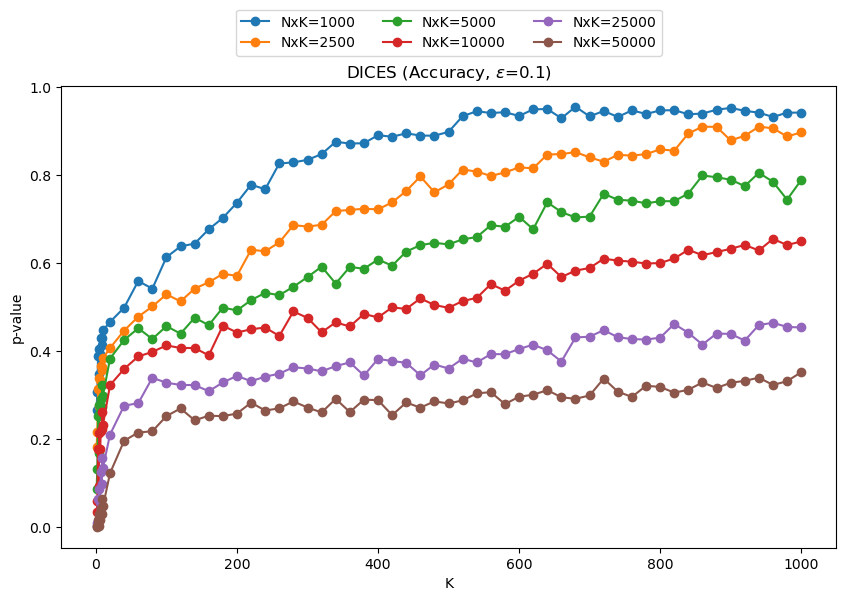

In [15]:
plt.figure(figsize=(10, 6))
# # plt.plot(df_ratings_500[col], df_ratings_500[f"{metric}_p-value"], marker='o', label='NxK=500') 
# # plt.plot(df_ratings_1000[col], df_ratings_1000[f"{metric}_p-value"], marker='o', label='NxK=1000') 
# # plt.plot(df_ratings_1500[col], df_ratings_1500[f"{metric}_p-value"], marker='o', label='NxK=1500') 
# # plt.plot(df_ratings_2000[col], df_ratings_2000[f"{metric}_p-value"], marker='o', label='NxK=2000')  
# # plt.plot(df_ratings_2500[col], df_ratings_2500[f"{metric}_p-value"], marker='o', label='NxK=2500') 
# # plt.plot(df_ratings_3000[col], df_ratings_3000[f"{metric}_p-value"], marker='o', label='NxK=3000')
# # plt.plot(df_ratings_3500[col], df_ratings_3500[f"{metric}_p-value"], marker='o', label='NxK=3500') 
# # plt.plot(df_ratings_4000[col], df_ratings_4000[f"{metric}_p-value"], marker='o', label='NxK=4000')
# # plt.plot(df_ratings_4500[col], df_ratings_4500[f"{metric}_p-value"], marker='o', label='NxK=4500') 
# plt.plot(df_ratings_5000[col], df_ratings_5000[f"{metric}_p-value"], marker='o', label='NxK=5000') 
# # plt.plot(df_ratings_5000[col], df_ratings_5000[f"{metric}_p-value"], marker='o', label='NxK=10000') 

for idx, nk in enumerate(data_nk_list):
    plt.plot(all_dfs[idx][col], all_dfs[idx][f"{metric}_p-value"], marker='o', label=f'NxK={nk}') 

plt.xlabel(col) 
plt.ylabel('p-value') 
# plt.ylim((0,0.6))
# plt.ylim((0,0.015))
# plt.ylim((0,1))
plt.title(f"{dataset} ({metric}, $\\epsilon$={distortion})") 
plt.legend(loc='upper center', bbox_to_anchor=(0.5, 1.18), ncols=3) 
# plt.savefig(f"{exp_dir}plots/{dataset}_{metric}_col_{col}_epsilon={distortion}.png")
# plt.savefig(f"output/{dataset}_nk_5000_{metric}_{col}_e_{distortion}.png")
# plt.savefig(f"output/{dataset}_p_vals_{metric}_{col}_e_{distortion}.png")
# plt.savefig(f"output/{dataset}_p_vals_{metric}_{col}_100_e_{distortion}.png")

In [16]:
params_str = get_bash_params_list(errors)
print(params_str)

()


In [17]:
# all_values 
# df_ratings_1000 = pd.concat([gather_data(n, k, [distortion]) for n,k in all_values]) 
# df_ratings_1000.head() 
# plt.figure() 
# plt.plot(df_ratings_1000["N"], df_ratings_1000["Accuracy_p-value"], label='Accuracy') 
# plt.plot(df_ratings_1000["N"], df_ratings_1000["F1-score_p-value"], label='F1-score') 
# plt.plot(df_ratings_1000["N"], df_ratings_1000["MAE_p-value"], label='MAE') 
# plt.xlabel('N') 
# plt.ylabel('p-value') 
# # plt.ylim((0,0.8)) 
# plt.title(f"DICES (N=1000, $\\epsilon$={distortion})") 
# plt.legend(loc='upper left', ncols=3)

In [18]:
# def plot_fig(df, col):
#     plt.figure() 
#     plt.plot(df[col], df["Accuracy_p-value"], label='Accuracy') 
#     # plt.plot(df_ratings_500["K"], df_ratings_500["F1-score_p-value"], label='F1-score') 
#     # plt.plot(df_ratings_500["K"], df_ratings_500["MAE_p-value"], label='MAE') 
#     plt.xlabel('K') 
#     plt.ylabel('p-value') 
#     # plt.ylim((0,0.8)) 
#     plt.title(f"DICES (NxK=500, $\\epsilon$={distortion})") 
#     plt.legend(loc='upper left', ncols=3) 
#     # plt.savefig(f"{exp_dir}plots/DICES_NxK=500_epsilon={distortion}.png")
# plot_fig(df_ratings_500, "K")

In [19]:
# plt.figure() 
# plt.plot(df_ratings_500["N"], df_ratings_500["Accuracy_p-value"], label='Accuracy') 
# # plt.plot(df_ratings_500["N"], df_ratings_500["F1-score_p-value"], label='F1-score') 
# # plt.plot(df_ratings_500["N"], df_ratings_500["MAE_p-value"], label='MAE') 
# plt.xlabel('N') 
# plt.ylabel('p-value') 
# # plt.ylim((0,0.8)) 
# plt.title(f"DICES (NxK=500, $\\epsilon$={distortion})") 
# plt.legend(loc='upper right', ncols=3) 
# # plt.savefig(f"{exp_dir}plots/DICES_NxK=500_epsilon={distortion}.png")